In [2]:
import nltk
nltk.download('book')
from nltk.book import *
from nltk.corpus import stopwords

[nltk_data] Downloading collection 'book'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package brown to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/brown.zip.
[nltk_data]    | Downloading package chat80 to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/chat80.zip.
[nltk_data]    | Downloading package cmudict to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/cmudict.zip.
[nltk_data]    | Downloading package conll2000 to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/conll2000.zip.
[nltk_data]    | Downloading package conll2002 to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/conll2002.zip.
[nltk_data]    | Downloading package dependency_treebank to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping corpora/dependency_treebank.zip.
[nltk_data]    | Downloading package genesis to /root/nltk_data...
[nltk_data]    

*** Introductory Examples for the NLTK Book ***
Loading text1, ..., text9 and sent1, ..., sent9
Type the name of the text or sentence to view it.
Type: 'texts()' or 'sents()' to list the materials.
text1: Moby Dick by Herman Melville 1851
text2: Sense and Sensibility by Jane Austen 1811
text3: The Book of Genesis
text4: Inaugural Address Corpus
text5: Chat Corpus
text6: Monty Python and the Holy Grail
text7: Wall Street Journal
text8: Personals Corpus
text9: The Man Who Was Thursday by G . K . Chesterton 1908


# RECURSO PARA TRADUCIR TEXTO

# SWADESH

In [3]:
from nltk.corpus import swadesh
#idiomas disponibles
print(swadesh.fileids())

['be', 'bg', 'bs', 'ca', 'cs', 'cu', 'de', 'en', 'es', 'fr', 'hr', 'it', 'la', 'mk', 'nl', 'pl', 'pt', 'ro', 'ru', 'sk', 'sl', 'sr', 'sw', 'uk']


In [4]:
traductor_es_en = swadesh.entries(['es','en'])
traductor_es_en

[('yo', 'I'),
 ('tú, usted', 'you (singular), thou'),
 ('él', 'he'),
 ('nosotros', 'we'),
 ('vosotros, ustedes', 'you (plural)'),
 ('ellos, ellas', 'they'),
 ('este', 'this'),
 ('ese, aquel', 'that'),
 ('aquí, acá', 'here'),
 ('ahí, allí, allá', 'there'),
 ('quien', 'who'),
 ('que', 'what'),
 ('donde', 'where'),
 ('cuando', 'when'),
 ('como', 'how'),
 ('no', 'not'),
 ('todo', 'all'),
 ('muchos', 'many'),
 ('algunos, unos', 'some'),
 ('poco', 'few'),
 ('otro', 'other'),
 ('uno', 'one'),
 ('dos', 'two'),
 ('tres', 'three'),
 ('cuatro', 'four'),
 ('cinco', 'five'),
 ('grande', 'big'),
 ('largo', 'long'),
 ('ancho', 'wide'),
 ('gordo', 'thick'),
 ('pesado', 'heavy'),
 ('pequeño', 'small'),
 ('corto', 'short'),
 ('estrecho, angosto', 'narrow'),
 ('delgado, flaco', 'thin'),
 ('mujer', 'woman'),
 ('hombre', 'man (adult male)'),
 ('hombre', 'man (human being)'),
 ('niño', 'child'),
 ('esposa, mujer', 'wife'),
 ('esposo, marido', 'husband'),
 ('madre', 'mother'),
 ('padre', 'father'),
 ('animal

In [6]:
traductor = dict(traductor_es_en)
traductor['lejos']

'far'

# WordNet
## Referencias

* [WordNet Lecture](https://sp1718.github.io/wordnet_lecture.pdf)
* [What is WordNet?](https://wordnet.princeton.edu)
* [WordNet Interface NLTK](http://www.nltk.org/howto/wordnet.html)
* [LAS-WordNet](https://www.datos.gov.co/Ciencia-Tecnolog-a-e-Innovaci-n/LAS-WordNet-una-WordNet-para-el-espa-ol-obtenida-c/8z8d-85m7)

In [7]:
nltk.download('omw-1.4')
from nltk.corpus import wordnet as wn

[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [8]:
# synset: grupo de sinómimos de una palabra.
ss = wn.synsets('carro', lang='spa')
ss

[Synset('car.n.01'),
 Synset('carriage.n.04'),
 Synset('carrier.n.02'),
 Synset('cart.n.01'),
 Synset('chariot.n.02'),
 Synset('cartload.n.01')]

In [9]:
# explorando los synsets
for syn in ss:
  print(syn.name(), ': ', syn.definition())
  for name in syn.lemma_names():
    print(' * ', name)

car.n.01 :  a motor vehicle with four wheels; usually propelled by an internal combustion engine
 *  car
 *  auto
 *  automobile
 *  machine
 *  motorcar
carriage.n.04 :  a machine part that carries something else
 *  carriage
carrier.n.02 :  a self-propelled wheeled vehicle designed specifically to carry something
 *  carrier
cart.n.01 :  a heavy open wagon usually having two wheels and drawn by an animal
 *  cart
chariot.n.02 :  a two-wheeled horse-drawn battle vehicle; used in war and races in ancient Egypt and Greece and Rome
 *  chariot
cartload.n.01 :  the quantity that a cart holds
 *  cartload


In [10]:
# visualization references
# * http://www.randomhacks.net/2009/12/29/visualizing-wordnet-relationships-as-graphs/
# * http://dlacombejr.github.io/programming/2015/09/28/visualizing-cifar-10-categories-with-wordnet-and-networkx.html

import networkx as nx
import matplotlib.pyplot as plt

def closure_graph(synset, fn):
    seen = set()
    graph = nx.DiGraph()
    labels = {}

    def recurse(s):
        if not s in seen:
            seen.add(s)
            labels[s.name] = s.name().split('.')[0]
            graph.add_node(s.name)
            for s1 in fn(s):
                graph.add_node(s1.name)
                graph.add_edge(s.name, s1.name)
                recurse(s1)

    recurse(synset)
    return graph, labels

def draw_text_graph(G, labels):
    plt.figure(figsize=(18,12))
    pos = nx.planar_layout(G, scale=18)
    nx.draw_networkx_nodes(G, pos, node_color="red", linewidths=0, node_size=500)
    nx.draw_networkx_labels(G, pos, font_size=20, labels=labels)
    nx.draw_networkx_edges(G, pos)
    plt.xticks([])
    plt.yticks([])

## **Hyponyms:** Conceptos que son más especificos que la palabra raiz de la cual derivan.

car.n.01


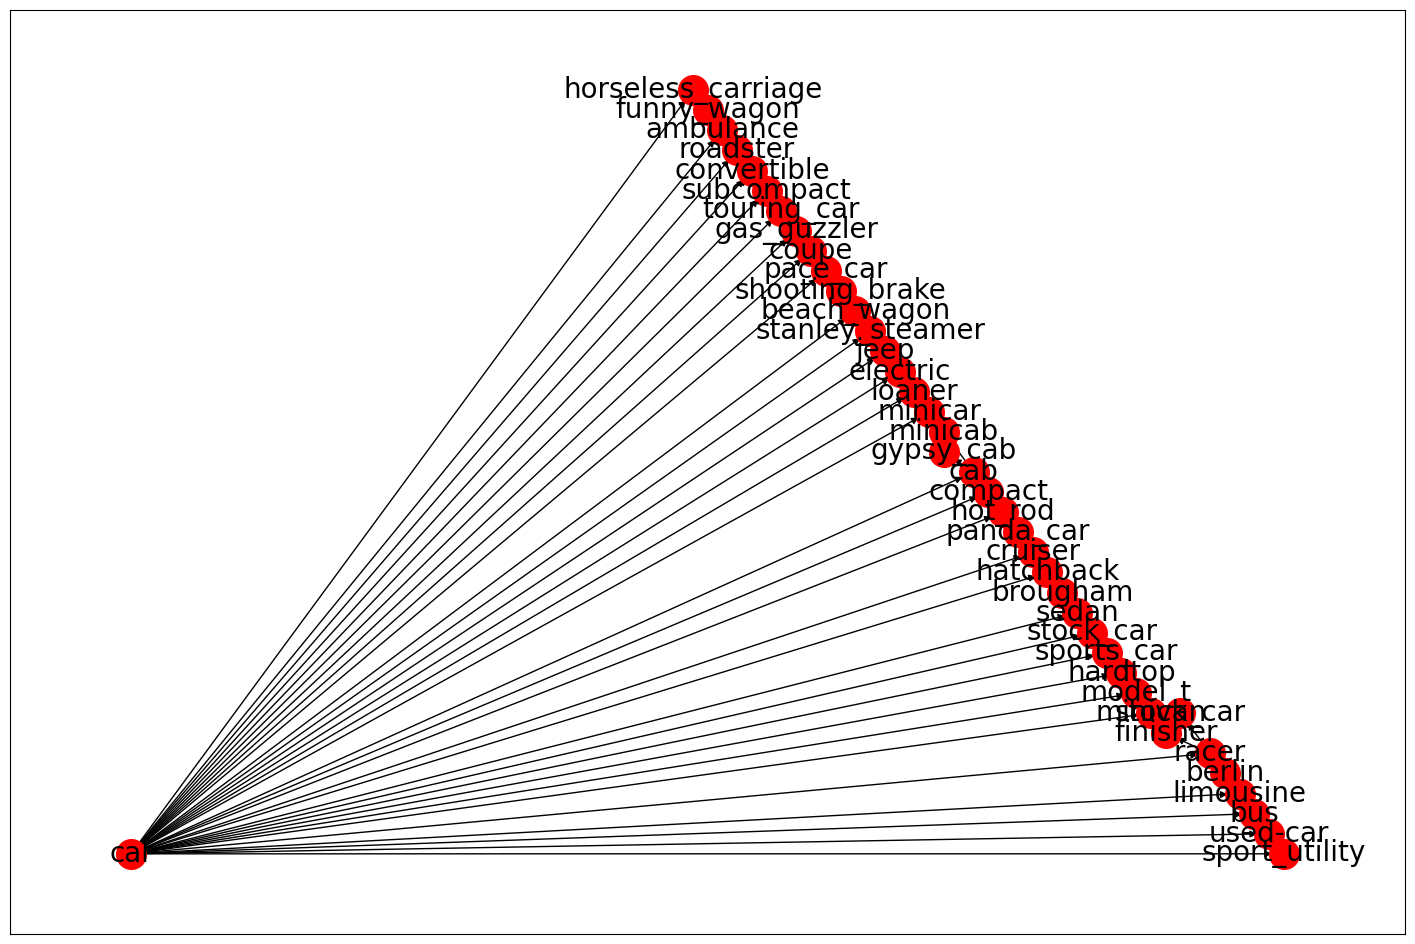

In [11]:
print(ss[0].name())
G, labels = closure_graph(ss[0], fn = lambda s: s.hyponyms())
draw_text_graph(G, labels)

## **Hypernyms**: conceptos que son mas generales !

car.n.01


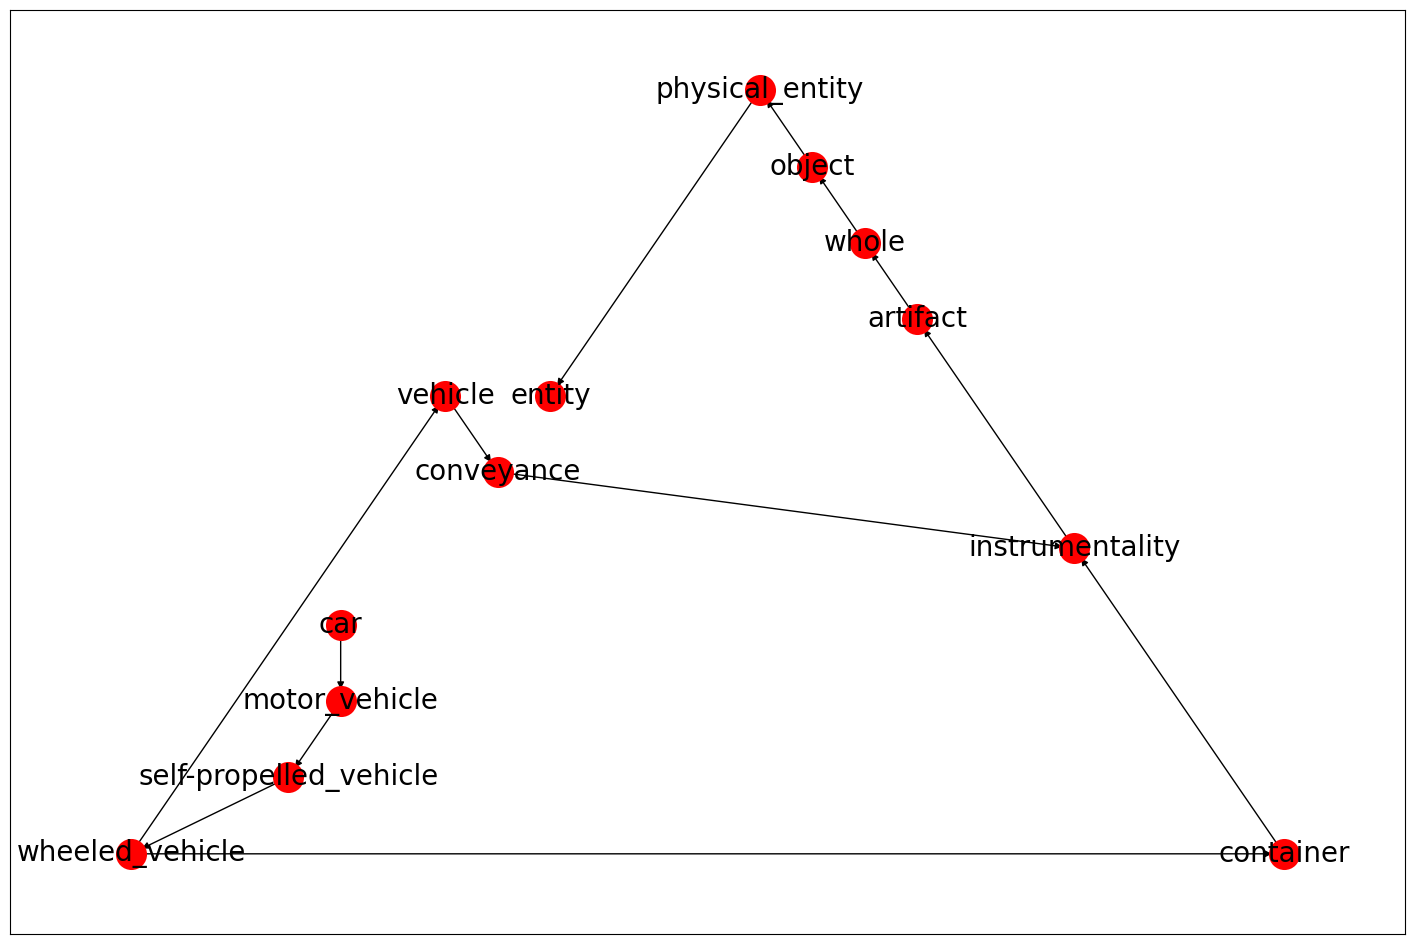

In [12]:
print(ss[0].name())
G, labels = closure_graph(ss[0], fn = lambda s: s.hypernyms())
draw_text_graph(G, labels)